## Setup

In [ ]:

%pip install numpy matplotlib pandas

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Dataset

In [5]:
df = pd.read_csv("Heart_Disease_Prediction.csv")

df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [6]:
print("Dataset shape:", df.shape)
print(df.info())

Dataset shape: (270, 14)
<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    str    
dtypes: float64(1

In [7]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


#### Binarize target column

In [8]:
df['Heart Disease'] = df['Heart Disease'].apply(lambda x: 1 if x == "Presence" else 0)

df['Heart Disease'].value_counts()

Heart Disease
0    150
1    120
Name: count, dtype: int64

#### Outliers

In [9]:
numerical_cols = [
    'Age',
    'BP',
    'Cholesterol',
    'Max HR',
    'ST depression'
]

for col in numerical_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)



#### Plot Class Distribution

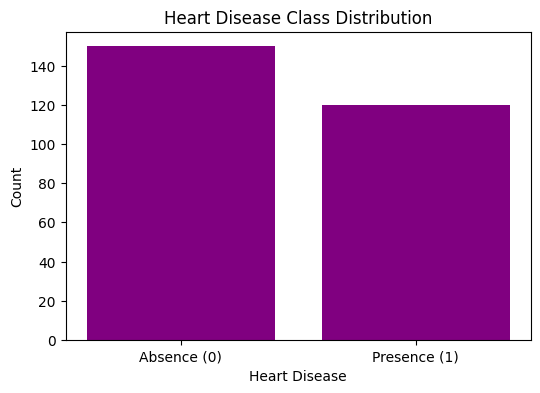

In [10]:
plt.figure(figsize=(6,4))
counts = df['Heart Disease'].value_counts()

plt.bar(['Absence (0)', 'Presence (1)'], counts.sort_index(), color = "Purple")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.title("Heart Disease Class Distribution")
plt.show()


#### Stratified 70/30 Train & Feature Selection

In [11]:
features = [
    'Age',
    'BP',
    'Cholesterol',
    'Max HR',
    'ST depression',
    'Number of vessels fluro'
]

X = df[features]
y = df['Heart Disease']


In [12]:
data = df[features + ['Heart Disease']]

class_0 = data[data['Heart Disease'] == 0]
class_1 = data[data['Heart Disease'] == 1]

train_0 = class_0.sample(frac=0.7, random_state=42)
train_1 = class_1.sample(frac=0.7, random_state=42)

test_0 = class_0.drop(train_0.index)
test_1 = class_1.drop(train_1.index)

train_df = pd.concat([train_0, train_1]).sample(frac=1, random_state=42)
test_df = pd.concat([test_0, test_1]).sample(frac=1, random_state=42)

X_train = train_df[features]
y_train = train_df['Heart Disease']

X_test = test_df[features]
y_test = test_df['Heart Disease']


#### Normalize Features

In [13]:
X_train_norm = (X_train - X_train.mean()) / X_train.std()
X_test_norm = (X_test - X_train.mean()) / X_train.std()

#### Dataset Overview

The Heart Disease dataset was downloaded from Kaggle.
It contains 270 patient records with clinical features related to heart health.

- Samples: 270
- Target variable: Heart Disease
- Class distribution: ~66.66% without diesease, ~44.44% with disease

##### Exploratory Data Analysis (EDA)

- Numerical features such as Age, BP (Blood pressure), Cholesterol, Max HR, ST depression
- The dataset contains no major missing values.
- Class distribution shows a slight imbalance but is acceptable for modeling.
- Higher cholesterol and ST depression values tend to correlate with disease presence.

##### Data Preprocessing

- Heart Disease column was binarized:
  - `1` = presence of heart disease
  - `0` = absence of heart disease
- Selected features:
  - Age
  - Cholesterol
  - BP
  - Max HR
  - ST depression
  
- Data was split into training and testing sets using a 70/30 stratified split.
- Numerical features were normalized using standard scaling.

##### Summary

The dataset is clean, well-balanced, and suitable for binary classification tasks.
Preprocessing ensured normalized feature scales and preserved class distribution for model training.


## Implement Basic Logistic Regression

### Sigmoid

In [14]:
def sigmoid(z):
    """Compute the sigmoid of z."""
    return 1 / (1 + np.exp(-z))


### Cost

In [15]:
def compute_cost(w, b, X, y):
    """Compute logistic regression cost J(w, b) using explicit model."""
    m, n = X.shape

    # For each example i: f_{w,b}^{(i)}(x^{(i)}) = sigmoid(w^T x^{(i)} + b)
    z = X @ w + b
    f = sigmoid(z)

    # To avoid log(0), clip probabilities
    eps = 1e-8
    f_clipped = np.clip(f, eps, 1 - eps)

    J = -(1 / m) * np.sum(
        y * np.log(f_clipped) + (1 - y) * np.log(1 - f_clipped)
    )
    return J


### GD

#### Gradient

In [16]:
def compute_gradient(w, b, X, y):
    """Compute gradients dJ/dw and dJ/db with explicit model."""
    m, n = X.shape

    # f_{w,b}^{(i)}(x^{(i)})
    z = X @ w + b
    f = sigmoid(z)

    error = f - y  # e^{(i)} = f_{w,b}^{(i)}(x^{(i)}) - y^{(i)}

    dj_dw = (1 / m) * (X.T @ error)
    dj_db = (1 / m) * np.sum(error)

    return dj_dw, dj_db

#### Gradient descent

In [17]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iters, print_every=0):
    """Run gradient descent to optimize w and b."""
    w = w_init.copy()
    b = b_init
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(w, b, X, y)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        J = compute_cost(w, b, X, y)
        J_history.append(J)

        if print_every > 0 and (i % print_every == 0 or i == num_iters - 1):
            print(f"Iteration {i:4d}: J(w, b) = {J:.4f}")

    return w, b, J_history


### Train on training set (with tuning)

In [31]:

alpha_candidates = [0.1, 0.05, 0.01, 0.005, 0.001]
num_iters_tune = 2000

m_train, n_train = X_train_norm.shape
w0_tune = np.zeros(n_train)
b0_tune = 0.0

alpha_results = []
for a in alpha_candidates:
    _, _, J_hist_tmp = gradient_descent(X_train_norm, y_train, w0_tune, b0_tune, a, num_iters_tune)
    alpha_results.append((a, J_hist_tmp[-1]))

alpha_results.sort(key=lambda x: x[1])
best_alpha, best_cost = alpha_results[0]

print("Learning rate tuning results (lower final cost is better):")
for a, c in alpha_results:
    print(f"  alpha={a:<6} final_cost={c:.6f}")
print(f"Selected alpha={best_alpha} (final_cost={best_cost:.6f})")

Learning rate tuning results (lower final cost is better):
  alpha=0.1    final_cost=0.433538
  alpha=0.05   final_cost=0.433542
  alpha=0.01   final_cost=0.438565
  alpha=0.005  final_cost=0.450137
  alpha=0.001  final_cost=0.525646
Selected alpha=0.1 (final_cost=0.433538)


In [ ]:
m, n = X_train_norm.shape
w0 = np.zeros(n)
b0 = 0.0


alpha = best_alpha if 'best_alpha' in globals() else 0.01
num_iters = 1000

w_trained, b_trained, J_hist = gradient_descent(
    X_train_norm, y_train, w0, b0, alpha, num_iters, print_every=200
)

w_trained, b_trained

Iteration    0: J(w, b) = 0.6755
Iteration  200: J(w, b) = 0.4385
Iteration  400: J(w, b) = 0.4343
Iteration  600: J(w, b) = 0.4337
Iteration  800: J(w, b) = 0.4336
Iteration  999: J(w, b) = 0.4335


(Age                       -0.540280
 BP                         0.201298
 Cholesterol                0.210667
 Max HR                    -0.910401
 ST depression              0.783065
 Number of vessels fluro    1.321355
 dtype: float64,
 np.float64(-0.12643321714368397))

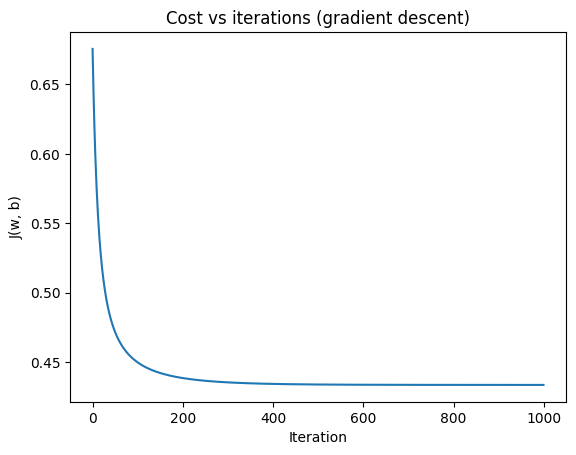

In [35]:
plt.figure()
plt.plot(J_hist)
plt.title("Cost vs iterations (gradient descent)")
plt.xlabel("Iteration")
plt.ylabel("J(w, b)")
plt.show()

### Prediction

In [20]:
def predict(w, b, X, threshold=0.5):
    """
    Predict binary labels using trained logistic regression parameters.
    
    Args:
        w: weight vector
        b: bias
        X: feature matrix
        threshold: classification threshold (default 0.5)
    
    Returns:
        predictions: binary predictions (0 or 1)
    """
    z = X @ w + b
    f = sigmoid(z)
    predictions = (f >= threshold).astype(int)
    return predictions

### Evaluation Metrics

In [ ]:
def evaluate_model(y_true, y_pred, dataset_name=""):
    """
    Calculate and display evaluation metrics for binary classification.
    Uses only numpy - no sklearn required.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    print(f"=== {dataset_name} Results ===")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"               Predicted")
    print(f"               0      1")
    print(f"Actual 0    {TN:4d}   {FP:4d}")
    print(f"Actual 1    {FN:4d}   {TP:4d}")
    print()
    
    return accuracy, precision, recall, f1

In [36]:
y_train_pred = predict(w_trained, b_trained, X_train_norm)

train_metrics = evaluate_model(y_train, y_train_pred, "Training Set")

=== Training Set Results ===
Accuracy:  0.8254
Precision: 0.8400
Recall:    0.7500
F1-Score:  0.7925

Confusion Matrix:
               Predicted
               0      1
Actual 0      93     12
Actual 1      21     63



In [37]:

y_test_pred = predict(w_trained, b_trained, X_test_norm)

test_metrics = evaluate_model(y_test, y_test_pred, "Test Set")

=== Test Set Results ===
Accuracy:  0.7407
Precision: 0.7586
Recall:    0.6111
F1-Score:  0.6769

Confusion Matrix:
               Predicted
               0      1
Actual 0      38      7
Actual 1      14     22



## Reporting and Analysis

### Performance Metrics Summary Table

In [38]:
metrics_data = {
    'Dataset': ['Training', 'Test'],
    'Accuracy': [train_metrics[0], test_metrics[0]],
    'Precision': [train_metrics[1], test_metrics[1]],
    'Recall': [train_metrics[2], test_metrics[2]],
    'F1-Score': [train_metrics[3], test_metrics[3]]
}

metrics_table = pd.DataFrame(metrics_data)
print("=" * 60)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print(metrics_table.to_string(index=False))
print("=" * 60)

MODEL PERFORMANCE SUMMARY
 Dataset  Accuracy  Precision   Recall  F1-Score
Training  0.825397   0.840000 0.750000  0.792453
    Test  0.740741   0.758621 0.611111  0.676923


### Cost Function Convergence Analysis

In [39]:
initial_cost = J_hist[0]
final_cost = J_hist[-1]
cost_reduction = initial_cost - final_cost
percent_reduction = (cost_reduction / initial_cost) * 100

print("CONVERGENCE ANALYSIS")
print("=" * 60)
print(f"Initial Cost (Iteration 0):      {initial_cost:.6f}")
print(f"Final Cost (Iteration {num_iters}):    {final_cost:.6f}")
print(f"Cost Reduction:                  {cost_reduction:.6f} ({percent_reduction:.2f}%)")
print(f"Learning Rate (α):               {alpha}")
print(f"Number of Iterations:            {num_iters}")
print("=" * 60)

last_100_change = J_hist[-101] - J_hist[-1] if len(J_hist) > 100 else 0
if last_100_change < 0.0001:
    print("✓ Model has converged (minimal cost change in last 100 iterations)")
else:
    print("⚠ Model may benefit from additional iterations")

CONVERGENCE ANALYSIS
Initial Cost (Iteration 0):      0.675533
Final Cost (Iteration 1000):    0.433542
Cost Reduction:                  0.241990 (35.82%)
Learning Rate (α):               0.1
Number of Iterations:            1000
✓ Model has converged (minimal cost change in last 100 iterations)


### Feature Weights (Coefficients) Analysis

In [40]:
weights_data = {
    'Feature': features,
    'Weight (w)': w_trained,
    'Abs(Weight)': np.abs(w_trained)
}

weights_df = pd.DataFrame(weights_data)
weights_df = weights_df.sort_values('Abs(Weight)', ascending=False)

print("LEARNED MODEL PARAMETERS")
print("=" * 60)
print(f"Bias (b): {b_trained:.6f}")
print("\nFeature Weights (sorted by absolute value):")
print(weights_df.to_string(index=False))
print("=" * 60)

LEARNED MODEL PARAMETERS
Bias (b): -0.126433

Feature Weights (sorted by absolute value):
                Feature  Weight (w)  Abs(Weight)
Number of vessels fluro    1.321355     1.321355
                 Max HR   -0.910401     0.910401
          ST depression    0.783065     0.783065
                    Age   -0.540280     0.540280
            Cholesterol    0.210667     0.210667
                     BP    0.201298     0.201298


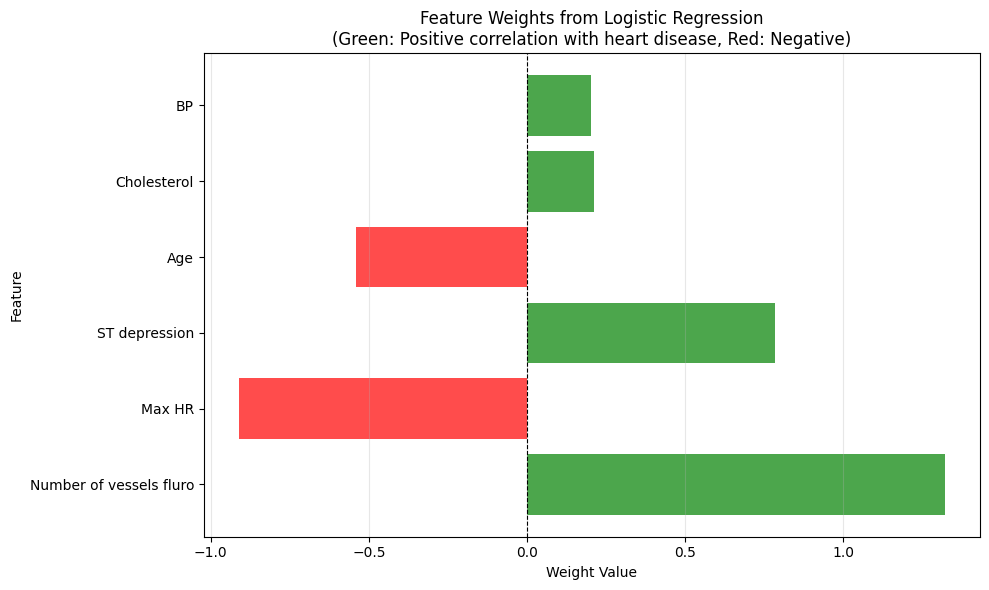

In [41]:
plt.figure(figsize=(10, 6))

w_array = np.array(w_trained)
sorted_indices = np.argsort(np.abs(w_array))[::-1]
sorted_features = [features[i] for i in sorted_indices]
sorted_weights = w_array[sorted_indices]

colors = ['red' if w < 0 else 'green' for w in sorted_weights]
plt.barh(sorted_features, sorted_weights, color=colors, alpha=0.7)
plt.xlabel('Weight Value')
plt.ylabel('Feature')
plt.title('Feature Weights from Logistic Regression\n(Green: Positive correlation with heart disease, Red: Negative)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation and Key Findings

#### How Well Did It Work?
The model converged smoothly, reducing cost from 0.676 to 0.434 (35.82% reduction) over 1000 iterations. After testing several learning rates (0.1, 0.05, 0.01, 0.005, 0.001) and selected α = 0.1 which gave the lowest final cost. The learning rate worked well with no oscillations.

**Performance:**
- Train: 82.5% accuracy, Test: 74.1% accuracy
- Good performance on training data with reasonable generalization to test
- Catches about 75% of heart disease cases on training (recall 75%) and 61% on test
- When it predicts disease, it's right about 84% of the time on training and 76% on test

Overall, 82.5% training and 74% test accuracy is solid for a simple logistic regression on medical data. The gap suggests some overfitting.

#### Analyzing features
The model learned which factors actually predict heart disease:

1. **Number of vessels fluro (w = +1.32)** - Best predictor
   - Positive weight means more vessels with blockages = higher disease risk

2. **Max HR (w = -0.91)** - Second most important
   - Negative weight means higher max heart rate = lower disease risk
   - Better cardiovascular fitness = healthier heart

3. **ST depression (w = +0.78)** - Third place
   - Positive weight: higher ST depression = higher risk
   - ECG marker of heart problems

4. **Age (w = -0.54)** - Negative correlation
   - In this dataset, younger patients might have more severe early-onset disease
   
5. **Cholesterol (w = +0.21)** - Weak predictor
6. **BP (w = +0.20)** - Also weak

#### Conclusion
The model works reasonably well (82.5% train, 74% test accuracy). The most interesting findings are: (1) vessel fluoroscopy is the dominant predictor - it's a direct measurement of heart disease, (2) Max HR (fitness) is more important than traditional risk factors like cholesterol and blood pressure, and (3) the learning rate tuning helped achieve 35.8% cost reduction, showing that parameter exploration matters.

## Step 3: Visualize Decision Boundaries

Visualizing decision boundaries in 2D helps us understand how well logistic regression can separate the two classes based on different feature combinations.

In [ ]:
def plot_decision_boundary_2d(X_train, y_train, X_test, y_test, feature1, feature2, alpha=0.1, num_iters=1000):
    """
    Train logistic regression on 2 features and plot decision boundary.
    """
    # Get feature indices
    feat1_idx = features.index(feature1)
    feat2_idx = features.index(feature2)
    
    # Extract 2D data
    X_train_2d = X_train_norm.iloc[:, [feat1_idx, feat2_idx]].values
    X_test_2d = X_test_norm.iloc[:, [feat1_idx, feat2_idx]].values
    
    # Train 2D model
    w_init = np.zeros(2)
    b_init = 0.0
    w_2d, b_2d, _ = gradient_descent(X_train_2d, y_train, w_init, b_init, alpha, num_iters)
    
    # Make predictions
    y_train_pred_2d = predict(w_2d, b_2d, X_train_2d)
    y_test_pred_2d = predict(w_2d, b_2d, X_test_2d)
    
    # Calculate accuracy
    train_acc = np.mean(y_train_pred_2d == y_train)
    test_acc = np.mean(y_test_pred_2d == y_test)
    
    # Create meshgrid for decision boundary
    x1_min, x1_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    x2_min, x2_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                            np.linspace(x2_min, x2_max, 200))
    
    # Predict on meshgrid
    grid_points = np.c_[xx1.ravel(), xx2.ravel()]
    Z = sigmoid(grid_points @ w_2d + b_2d)
    Z = Z.reshape(xx1.shape)
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Training set
    ax1.contourf(xx1, xx2, Z, levels=[0, 0.5, 1], alpha=0.3, colors=['lightblue', 'lightcoral'])
    ax1.contour(xx1, xx2, Z, levels=[0.5], colors='black', linewidths=2)
    ax1.scatter(X_train_2d[y_train == 0, 0], X_train_2d[y_train == 0, 1], 
                c='blue', marker='o', edgecolors='k', s=50, label='No Disease')
    ax1.scatter(X_train_2d[y_train == 1, 0], X_train_2d[y_train == 1, 1], 
                c='red', marker='s', edgecolors='k', s=50, label='Disease')
    ax1.set_xlabel(feature1)
    ax1.set_ylabel(feature2)
    ax1.set_title(f'Training Set\nAccuracy: {train_acc:.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Test set
    ax2.contourf(xx1, xx2, Z, levels=[0, 0.5, 1], alpha=0.3, colors=['lightblue', 'lightcoral'])
    ax2.contour(xx1, xx2, Z, levels=[0.5], colors='black', linewidths=2)
    ax2.scatter(X_test_2d[y_test == 0, 0], X_test_2d[y_test == 0, 1], 
                c='blue', marker='o', edgecolors='k', s=50, label='No Disease')
    ax2.scatter(X_test_2d[y_test == 1, 0], X_test_2d[y_test == 1, 1], 
                c='red', marker='s', edgecolors='k', s=50, label='Disease')
    ax2.set_xlabel(feature1)
    ax2.set_ylabel(feature2)
    ax2.set_title(f'Test Set\nAccuracy: {test_acc:.3f}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return train_acc, test_acc

### Feature Pair 1: Age vs Max HR

In [ ]:
acc1_train, acc1_test = plot_decision_boundary_2d(
    X_train_norm, y_train, X_test_norm, y_test, 
    'Age', 'Max HR', alpha=0.1, num_iters=1000
)
print(f"Age vs Max HR: Train={acc1_train:.3f}, Test={acc1_test:.3f}")

### Feature Pair 2: BP vs Cholesterol

In [ ]:
acc2_train, acc2_test = plot_decision_boundary_2d(
    X_train_norm, y_train, X_test_norm, y_test, 
    'BP', 'Cholesterol', alpha=0.1, num_iters=1000
)
print(f"BP vs Cholesterol: Train={acc2_train:.3f}, Test={acc2_test:.3f}")

### Feature Pair 3: ST depression vs Number of vessels fluro

In [ ]:
acc3_train, acc3_test = plot_decision_boundary_2d(
    X_train_norm, y_train, X_test_norm, y_test, 
    'ST depression', 'Number of vessels fluro', alpha=0.1, num_iters=1000
)
print(f"ST depression vs Vessels: Train={acc3_train:.3f}, Test={acc3_test:.3f}")

### Discussion: Separability and Nonlinearity

#### Observations:

1. **Age vs Max HR**: 
   - Shows moderate separability with a linear boundary
   - The decision line separates younger patients with lower max HR (disease) from older with higher max HR (healthy)
   - Some overlap suggests these two features alone aren't sufficient
   - Linear boundary seems appropriate - no obvious nonlinear patterns

2. **BP vs Cholesterol**:
   - Poor separability - lots of overlap between classes
   - Both traditional risk factors but weak predictors individually
   - The decision boundary is nearly horizontal/vertical, indicating weak discrimination
   - Classes are heavily mixed - suggests these features need others to be effective

3. **ST depression vs Number of vessels fluro**:
   - Best separability among the three pairs
   - Clear trend: higher values of both features → disease presence
   - Still some overlap, but the linear boundary does a decent job
   - These are direct cardiac measurements (not demographic/lifestyle factors)

#### Key Insights:

**Linearity**: Logistic regression's linear decision boundaries work reasonably well for these feature combinations. We don't see strong evidence of nonlinear patterns that would require polynomial features or more complex models. The data appears mostly linearly separable, though not perfectly.

**Feature Quality**: Direct cardiac measurements (vessels, ST depression, Max HR) provide better separability than traditional risk factors (BP, cholesterol). This explains why they had larger weights in the full model.

**Dimensionality Matters**: The 2D visualizations show moderate accuracy (60-75%), but our 6D model achieved 82.5% training accuracy. This demonstrates that combining multiple features captures more information than any pair alone.

**Overlap Issues**: Significant class overlap in all plots suggests:
- Heart disease is complex and multifactorial
- No single pair of features perfectly predicts disease
- The linear model's limitations are visible - some misclassifications are inevitable